In [19]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Aplicación de Regresion Lineal, Lasso, Ridge, Multiple
# versión: 1.0
#########################################################################

In [20]:
# ========================
# 1. LIBRERÍAS
# ========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import shapiro


In [21]:
# Cargar dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Variables principales
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Columnas importantes:

-  MedInc = Ingreso medio de la zona
-  HouseAge = Edad promedio de casas
-  AveRooms = Habitaciones promedio
-  AveOccup = Ocupación promedio
-  MedHouseVal = Precio medio de la vivienda (variable objetivo)

# Regresion Lineal (Ingreso vs Precio)

In [22]:
X = df[["MedInc"]]  # Ingreso medio
y = df["MedHouseVal"]  # Precio medio

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [24]:
y_pred = lin_reg.predict(X)
residuos = y - y_pred

In [25]:
print("Coeficiente pendiente:", lin_reg.coef_[0])
print("Intercepto:", lin_reg.intercept_)

Coeficiente pendiente: 0.41793849201896277
Intercepto: 0.45085576703267893


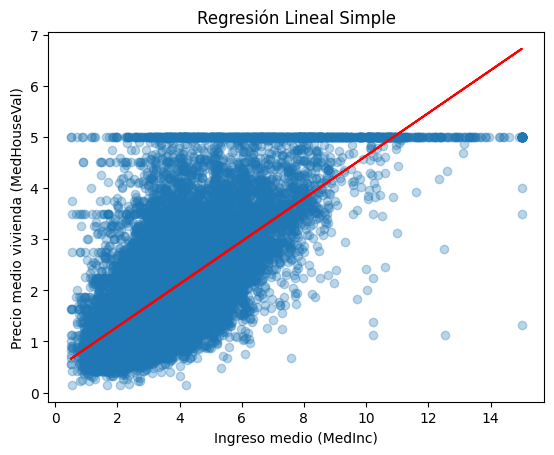

In [26]:
# Gráfico
plt.scatter(X, y, alpha=0.3)
plt.plot(X, y_pred, color="red")
plt.xlabel("Ingreso medio (MedInc)")
plt.ylabel("Precio medio vivienda (MedHouseVal)")
plt.title("Regresión Lineal Simple")
plt.show()

## Validación Supuestos

### Linealidad

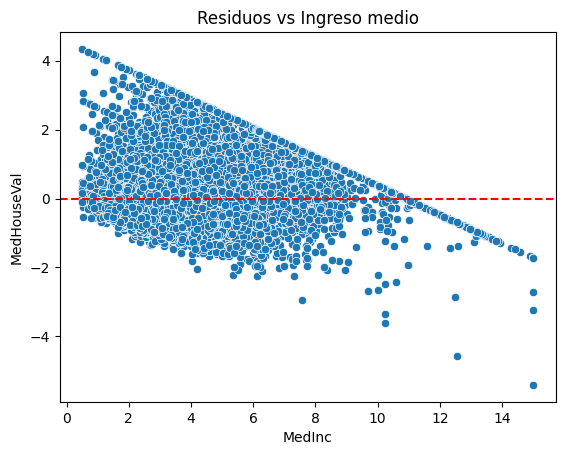

In [27]:
sns.scatterplot(x=X["MedInc"], y=residuos)
plt.axhline(0, color="red", ls="--")
plt.title("Residuos vs Ingreso medio")
plt.show()

### Independencia de Errores

In [28]:
from statsmodels.stats.stattools import durbin_watson


In [29]:
# Modelo con statsmodels
X_sm = sm.add_constant(X)
modelo = sm.OLS(y, X_sm).fit()

# Test de independencia (Durbin-Watson)
dw = durbin_watson(modelo.resid)
print("Durbin-Watson:", dw)

Durbin-Watson: 0.6545256909553094


✅ Interpretación del resultado

*  '= 2.0 → errores independientes (supuesto cumplido).
*  '< 1.5 → autocorrelación positiva (mal).
*  '> 2.5 → autocorrelación negativa (mal).

### Homocedasticidad

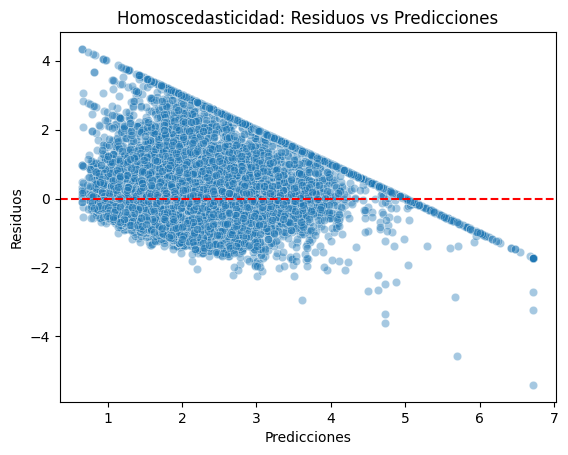

In [30]:
sns.scatterplot(x=y_pred, y=residuos, alpha=0.4)
plt.axhline(0, color="red", ls="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Homoscedasticidad: Residuos vs Predicciones")
plt.show()

### Normalidad de Residuos

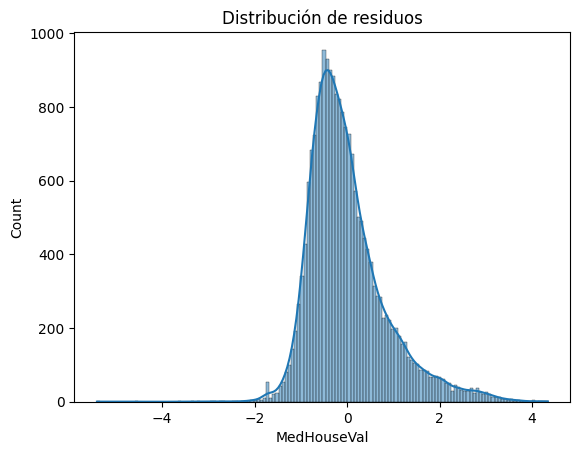

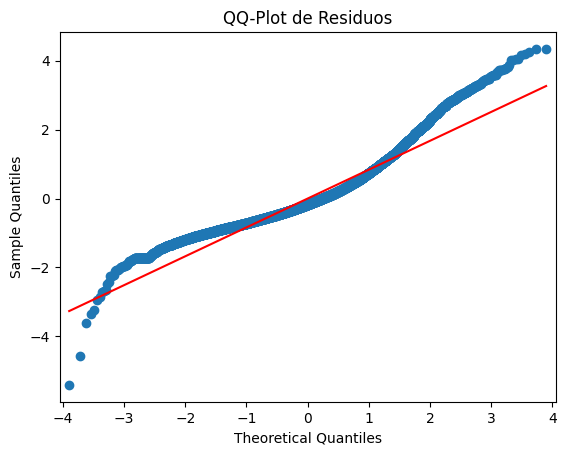

Shapiro-Wilk p-value: 9.056648035003807e-16


In [31]:
sns.histplot(residuos, kde=True)
plt.title("Distribución de residuos")
plt.show()

sm.qqplot(residuos, line="s")
plt.title("QQ-Plot de Residuos")
plt.show()

stat, p = shapiro(residuos.sample(500))  # Shapiro con muestra (dataset grande)
print("Shapiro-Wilk p-value:", p)

# Regresion Multiple

In [32]:
X_multi = df[["MedInc", "HouseAge", "AveRooms", "AveOccup"]]
y = df["MedHouseVal"]

X_sm = sm.add_constant(X_multi)
modelo_multi = sm.OLS(y, X_sm).fit()
print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     5450.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:24:45   Log-Likelihood:                -24802.
No. Observations:               20640   AIC:                         4.961e+04
Df Residuals:                   20635   BIC:                         4.965e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0314      0.022      1.428      0.1

# Regresion Lasso y Ridge

In [33]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
print("Coef Lasso:", pd.Series(lasso.coef_, index=X.columns))
print("R2 test (Lasso):", r2_score(y_test, lasso.predict(X_test)))


Coef Lasso: MedInc        0.406949
HouseAge      0.010286
AveRooms     -0.047312
AveBedrms     0.366137
Population    0.000001
AveOccup     -0.003209
Latitude     -0.405771
Longitude    -0.414832
dtype: float64
R2 test (Lasso): 0.5997745477668093


In [35]:
# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Coef Ridge:", pd.Series(ridge.coef_, index=X.columns))
print("R2 test (Ridge):", r2_score(y_test, ridge.predict(X_test)))

Coef Ridge: MedInc        4.456403e-01
HouseAge      9.683907e-03
AveRooms     -1.217486e-01
AveBedrms     7.766705e-01
Population   -7.704474e-07
AveOccup     -3.369492e-03
Latitude     -4.185296e-01
Longitude    -4.336561e-01
dtype: float64
R2 test (Ridge): 0.5958178603951636


Diferencia con Lasso, Ridge y Múltiple

✅ Regresión Lineal (simple o múltiple):
Debemos validar los 4 supuestos porque el modelo depende fuertemente de ellos para ser confiable.

✅ Regresión Ridge y Lasso:
Son extensiones de la lineal, pero como aplican regularización (penalizan coeficientes) relajan un poco la dependencia de los supuestos.

- Linealidad sigue siendo deseable.
- Homoscedasticidad y normalidad son menos críticas si el objetivo es predicción.
- Independencia sigue siendo necesaria.

✅ Regresión Múltiple:
Los mismos 4 supuestos aplican, pero además es clave revisar:

- Multicolinealidad entre predictores (VIF).
- Significancia estadística de cada variable (p-values).

| Supuesto                 | Lineal                     | Múltiple       | Lasso                         | Ridge                         |
| ------------------------ | -------------------------- | -------------- | ----------------------------- | ----------------------------- |
| Linealidad               | Obligatoria                | Obligatoria    | Sí, pero regularización ayuda | Sí, pero regularización ayuda |
| Independencia de errores | Obligatoria                | Obligatoria    | Obligatoria                   | Obligatoria                   |
| Homoscedasticidad        | Muy importante             | Muy importante | Menos crítico                 | Menos crítico                 |
| Normalidad de residuos   | Importante para inferencia | Importante     | Menos crítico                 | Menos crítico                 |
| Multicolinealidad        | N/A                        | Revisar (VIF)  | Se corrige (algunos coef → 0) | Se corrige (coef reducidos)   |


# Comparación Entre Regresiones

In [36]:
# ==========================================
# COMPARACIÓN: Lineal, Múltiple, Lasso, Ridge
# Dataset: California Housing (sklearn)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [37]:
# -----------------------------
# 1) Cargar dataset
# -----------------------------
def load_california_df():
    try:
        data = fetch_california_housing(as_frame=True)
        df = data.frame.copy()
        y = df["MedHouseVal"]
        X = df.drop(columns=["MedHouseVal"])
        feature_names = X.columns.tolist()
        return X, y, feature_names
    except Exception as e:
        print("No se pudo descargar California Housing:", e)
        print("Cargando desde CSV... (ajusta la ruta y el nombre de la columna target)")
        # ====== OPCIÓN CSV (si no hay internet) ======
        # df = pd.read_csv("/path/a/tu_california.csv")
        # y = df["MedHouseVal"]
        # X = df.drop(columns=["MedHouseVal"])
        # return X, y, X.columns.tolist()
        raise

X, y, feature_names = load_california_df()

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [38]:
# ==========================
# 2) Modelos a comparar
# ==========================
# Todos con StandardScaler para comparar coeficientes en la misma escala
# LINEAL SIMPLE: solo una variable (MedInc)
pipe_lin_simple = make_pipeline(
    StandardScaler(with_mean=True),
    LinearRegression()
)

# LINEAL MÚLTIPLE: todas las variables
pipe_lin_multi = make_pipeline(
    StandardScaler(with_mean=True),
    LinearRegression()
)

# LASSO con búsqueda de alpha por CV
alphas_lasso = np.logspace(-3, 1, 30)  # 0.001 a 10
pipe_lasso = make_pipeline(
    StandardScaler(with_mean=True),
    LassoCV(alphas=alphas_lasso, cv=KFold(n_splits=5, shuffle=True, random_state=42),
            random_state=42, max_iter=20000)
)

# RIDGE con búsqueda de alpha por CV
alphas_ridge = np.logspace(-3, 3, 40)  # 0.001 a 1000
pipe_ridge = make_pipeline(
    StandardScaler(with_mean=True),
    RidgeCV(alphas=alphas_ridge, cv=KFold(n_splits=5, shuffle=True, random_state=42))
)


In [39]:
# ==========================
# 3) Entrenar
# ==========================
# Lineal simple: X = MedInc
pipe_lin_simple.fit(X_train[["MedInc"]], y_train)

# Lineal múltiple: X = todas
pipe_lin_multi.fit(X_train, y_train)

# Lasso y Ridge
pipe_lasso.fit(X_train, y_train)
pipe_ridge.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridgecv',
                 RidgeCV(alphas=array([1.00000000e-03, 1.42510267e-03, 2.03091762e-03, 2.89426612e-03,
       4.12462638e-03, 5.87801607e-03, 8.37677640e-03, 1.19377664e-02,
       1.70125428e-02, 2.42446202e-02, 3.45510729e-02, 4.92388263e-02,
       7.01703829e-02, 1.00000000e-01, 1.42510267e-01, 2.03091762e-01,
       2.89426612e-01, 4.12462638...
       1.19377664e+00, 1.70125428e+00, 2.42446202e+00, 3.45510729e+00,
       4.92388263e+00, 7.01703829e+00, 1.00000000e+01, 1.42510267e+01,
       2.03091762e+01, 2.89426612e+01, 4.12462638e+01, 5.87801607e+01,
       8.37677640e+01, 1.19377664e+02, 1.70125428e+02, 2.42446202e+02,
       3.45510729e+02, 4.92388263e+02, 7.01703829e+02, 1.00000000e+03]),
                         cv=KFold(n_splits=5, random_state=42, shuffle=True)))])

In [40]:
# ==========================
# 4) Predicciones y métricas
# ==========================
def eval_model(pipe, Xtr, Xte, ytr, yte):
    yhat_tr = pipe.predict(Xtr)
    yhat_te = pipe.predict(Xte)
    return {
        "R2_train": r2_score(ytr, yhat_tr),
        "R2_test": r2_score(yte, yhat_te),
        "RMSE_test": mean_squared_error(yte, yhat_te),
        "MAE_test": mean_absolute_error(yte, yhat_te),
    }, yhat_te

metrics = {}
yhat = {}

metrics["Lineal_simple (MedInc)"], yhat["Lineal_simple (MedInc)"] = eval_model(
    pipe_lin_simple, X_train[["MedInc"]], X_test[["MedInc"]], y_train, y_test
)
metrics["Lineal_múltiple (todas)"], yhat["Lineal_múltiple (todas)"] = eval_model(
    pipe_lin_multi, X_train, X_test, y_train, y_test
)
metrics["LassoCV"], yhat["LassoCV"] = eval_model(
    pipe_lasso, X_train, X_test, y_train, y_test
)
metrics["RidgeCV"], yhat["RidgeCV"] = eval_model(
    pipe_ridge, X_train, X_test, y_train, y_test
)

summary = (pd.DataFrame(metrics)
           .T[["R2_train","R2_test","RMSE_test","MAE_test"]]
           .sort_values("R2_test", ascending=False))
print("\n=== COMPARATIVO DE MÉTRICAS ===")
print(summary.round(4))

# Mostrar los alphas elegidos
lasso_alpha = pipe_lasso.named_steps["lassocv"].alpha_
ridge_alpha = pipe_ridge.named_steps["ridgecv"].alpha_
print(f"\nAlpha elegido (LassoCV): {lasso_alpha:.6f}")
print(f"Alpha elegido (RidgeCV): {ridge_alpha:.6f}")



=== COMPARATIVO DE MÉTRICAS ===
                         R2_train  R2_test  RMSE_test  MAE_test
LassoCV                    0.6098   0.5919     0.5400    0.5297
RidgeCV                    0.6099   0.5911     0.5410    0.5297
Lineal_múltiple (todas)    0.6099   0.5911     0.5411    0.5297
Lineal_simple (MedInc)     0.4743   0.4708     0.7002    0.6269

Alpha elegido (LassoCV): 0.001000
Alpha elegido (RidgeCV): 3.455107


In [41]:
# ==========================
# 5) Coeficientes comparables
# ==========================
# OJO: Como usamos StandardScaler en pipeline, los coeficientes corresponden a features estandarizados.
coef_table = pd.DataFrame(index=feature_names)

# Lineal múltiple
coef_table["Linear"] = pipe_lin_multi.named_steps["linearregression"].coef_

# Lasso y Ridge
coef_table["Lasso"] = pipe_lasso.named_steps["lassocv"].coef_
coef_table["Ridge"] = pipe_ridge.named_steps["ridgecv"].coef_

coef_table = coef_table.sort_index()
print("\n=== COEFICIENTES (features estandarizadas) ===")
print(coef_table.round(4))


=== COEFICIENTES (features estandarizadas) ===
            Linear   Lasso   Ridge
AveBedrms   0.3486  0.3350  0.3476
AveOccup   -0.0412 -0.0402 -0.0412
AveRooms   -0.3021 -0.2886 -0.3013
HouseAge    0.1207  0.1215  0.1209
Latitude   -0.8931 -0.8822 -0.8904
Longitude  -0.8678 -0.8562 -0.8650
MedInc      0.8521  0.8468  0.8519
Population -0.0016 -0.0004 -0.0016


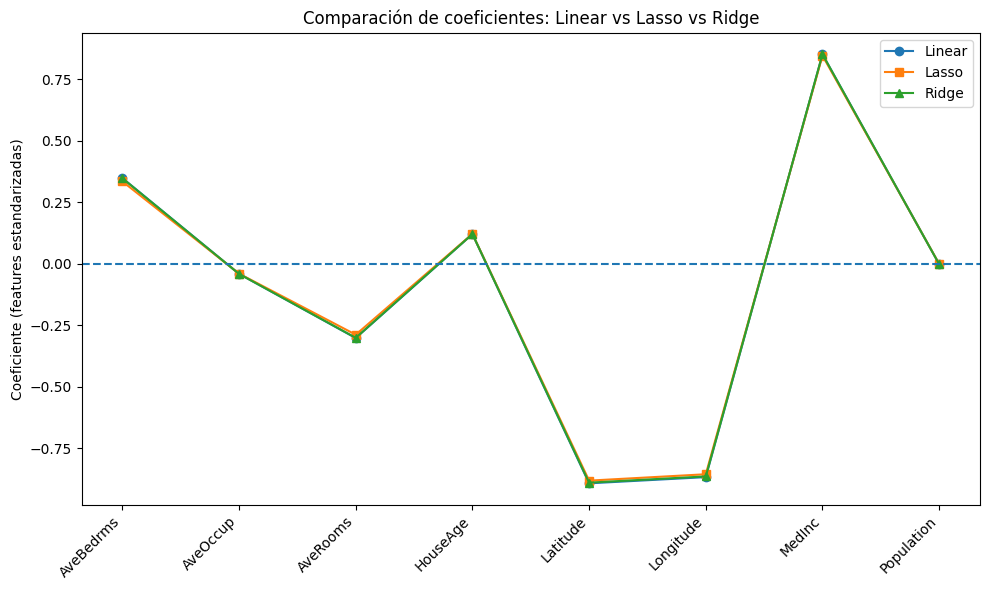

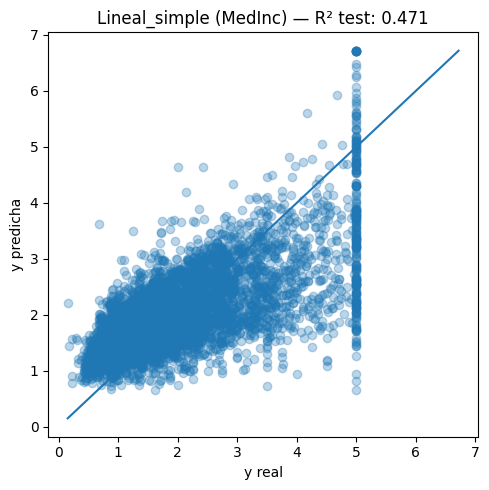

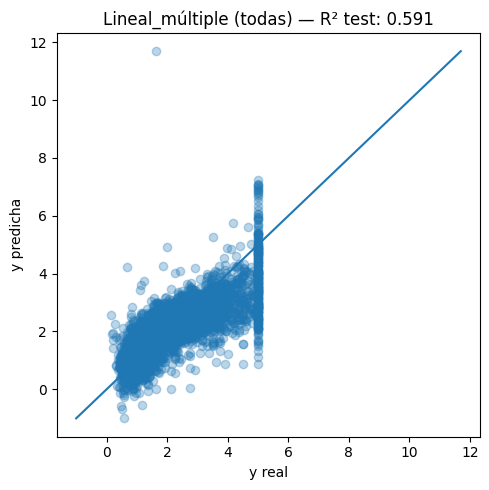

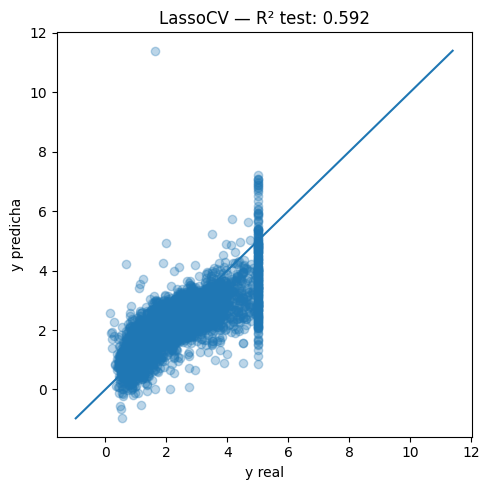

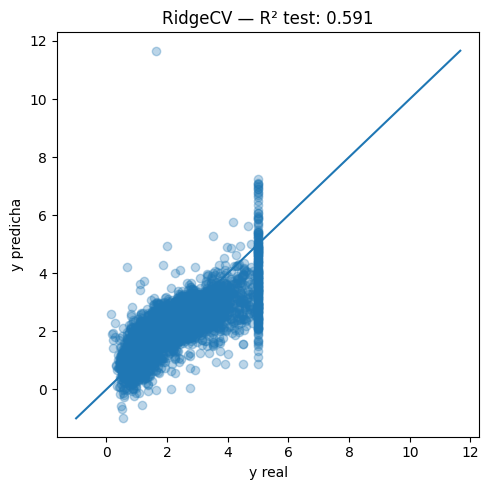

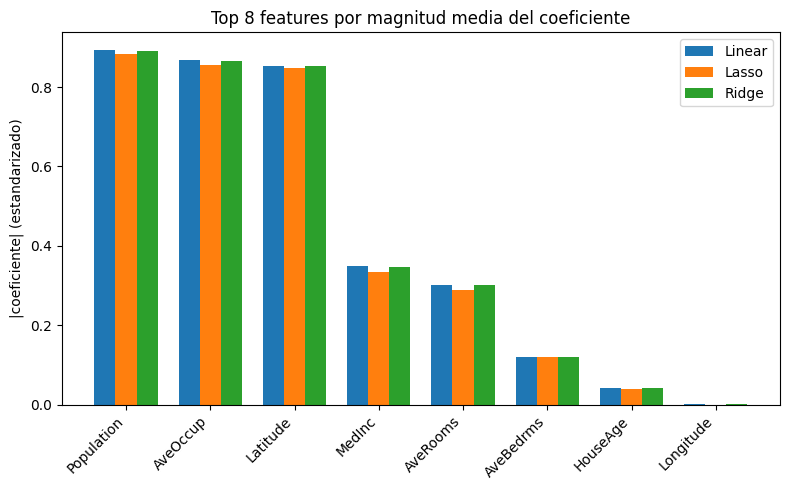

In [42]:
# ==========================
# 6) GRÁFICOS
# ==========================

# (A) Coeficientes por modelo
plt.figure(figsize=(10, 6))
x = np.arange(len(coef_table.index))
plt.plot(x, coef_table["Linear"].values, marker='o', label="Linear")
plt.plot(x, coef_table["Lasso"].values, marker='s', label="Lasso")
plt.plot(x, coef_table["Ridge"].values, marker='^', label="Ridge")
plt.axhline(0, linestyle='--')
plt.xticks(x, coef_table.index, rotation=45, ha='right')
plt.ylabel("Coeficiente (features estandarizadas)")
plt.title("Comparación de coeficientes: Linear vs Lasso vs Ridge")
plt.legend()
plt.tight_layout()
plt.show()

# (B) y_real vs y_pred en TEST para cada modelo
models_order = ["Lineal_simple (MedInc)", "Lineal_múltiple (todas)", "LassoCV", "RidgeCV"]
for name in models_order:
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, yhat[name], alpha=0.3)
    # línea ideal y = x
    lims = [min(y_test.min(), yhat[name].min()), max(y_test.max(), yhat[name].max())]
    plt.plot(lims, lims)
    plt.xlabel("y real")
    plt.ylabel("y predicha")
    plt.title(f"{name} — R² test: {r2_score(y_test, yhat[name]):.3f}")
    plt.tight_layout()
    plt.show()

# (C) Importancia relativa (|coef| normalizados) top-N
topN = 8
abs_coefs = pd.DataFrame({
    "feature": feature_names,
    "Linear": np.abs(coef_table["Linear"].values),
    "Lasso": np.abs(coef_table["Lasso"].values),
    "Ridge": np.abs(coef_table["Ridge"].values),
})
abs_coefs["mean_abs"] = abs_coefs[["Linear","Lasso","Ridge"]].mean(axis=1)
abs_top = abs_coefs.sort_values("mean_abs", ascending=False).head(topN)

plt.figure(figsize=(8, 5))
width = 0.25
idx = np.arange(len(abs_top))
plt.bar(idx - width, abs_top["Linear"], width, label="Linear")
plt.bar(idx,         abs_top["Lasso"],  width, label="Lasso")
plt.bar(idx + width, abs_top["Ridge"],  width, label="Ridge")
plt.xticks(idx, abs_top["feature"], rotation=45, ha='right')
plt.ylabel("|coeficiente| (estandarizado)")
plt.title(f"Top {topN} features por magnitud media del coeficiente")
plt.legend()
plt.tight_layout()
plt.show()
